### Equipo 11
### 2.2 Google Colab - Simple_ImgProcessing

    Jose Angel Barajas A01797221
    Andrés Marcelo Fernández Loredo A01281054
    Héctor Gerardo Paredes Castillo A01796892
    Gilberto Valencia Acosta A01273602

# 1. Simple Image Operations

## Table of Contents
1. [Libraries](#libraries)
2. [Loading Images](#loading)
3. [Resizing Images](#resize)
4. [Negative Images](#negative)
5. [Logarithmic Transformation](#log)
6. [Image Binarizer](#bin)
7. [Image Quantizer](#quant)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [64]:
from matplotlib import image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import cv2

## Loading Images <a class="anchor" id="loading"></a>

<class 'numpy.ndarray'>


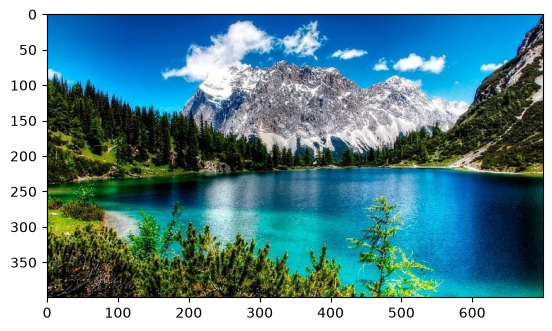

In [65]:
img1 = mpimg.imread('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image.jpg')
plt.imshow(img1)
print(type(img1))

Look at the shape of this array:

In [66]:
img1.shape

(400, 700, 3)

The image is actually composed of three "layers, or *channels*, for red, green, and blue (RGB) pixel intensities.

Display the same image but this time we'll use another popular Python library for working with images - **cv2**.

numpy.ndarray

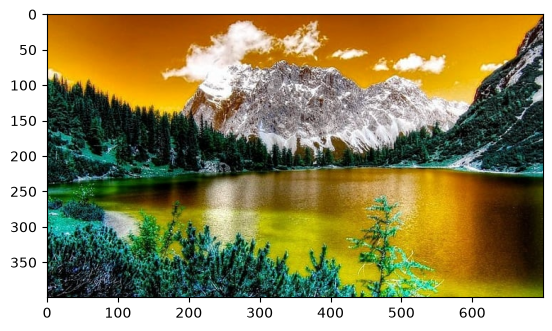

In [67]:
img2 = cv2.imread('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image.jpg')
plt.imshow(img2)
type(img2)

The trouble is that cv2 loads the array of image data with the channels ordered as blue, green, red (BGR) instead of red, green blue (RGB). 

Let's fix that

AxesImage(shape=(400, 700, 3))


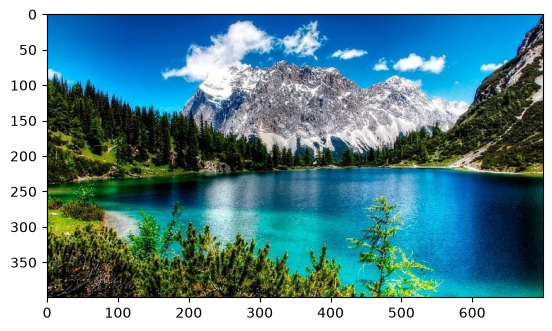

In [68]:
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
print(plt.imshow(img2))

Lastly, one more commonly used library for image processing in Python we should consider - **PIL**:

<class 'PIL.JpegImagePlugin.JpegImageFile'>


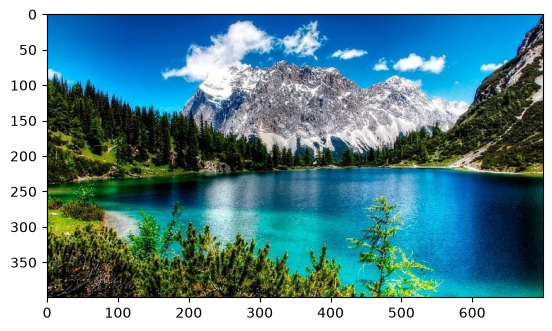

In [69]:
from PIL import Image
import matplotlib.pyplot as plt

img3 = Image.open('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image.jpg')
plt.imshow(img3)
print(type(img3))

It's easy to convert a PIL JpegImageFile to a numpy array

In [70]:
img3 = np.array(img3)
img3.shape

(400, 700, 3)

Saving a numpy array in an optimized format, should you need to persist images into storage

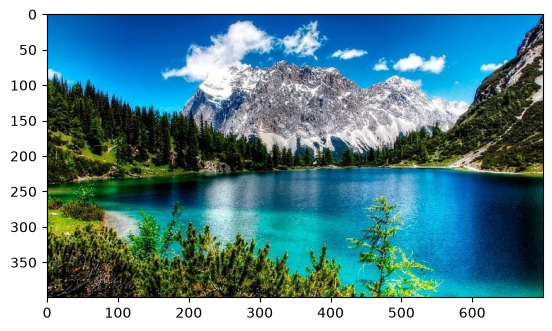

In [71]:
# Save the image
np.save('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/img.npy', img3)

# Load the image
img3 = np.load('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/img.npy')

plt.imshow(img3)

## Resizing an Image <a class="anchor" id="resize"></a>
One of the most common manipulations of an image is to resize it. 

Generally, we want to ensure that all of your training images have consistent dimensions.

Original size: 700 x 400
New size: 200 x 200


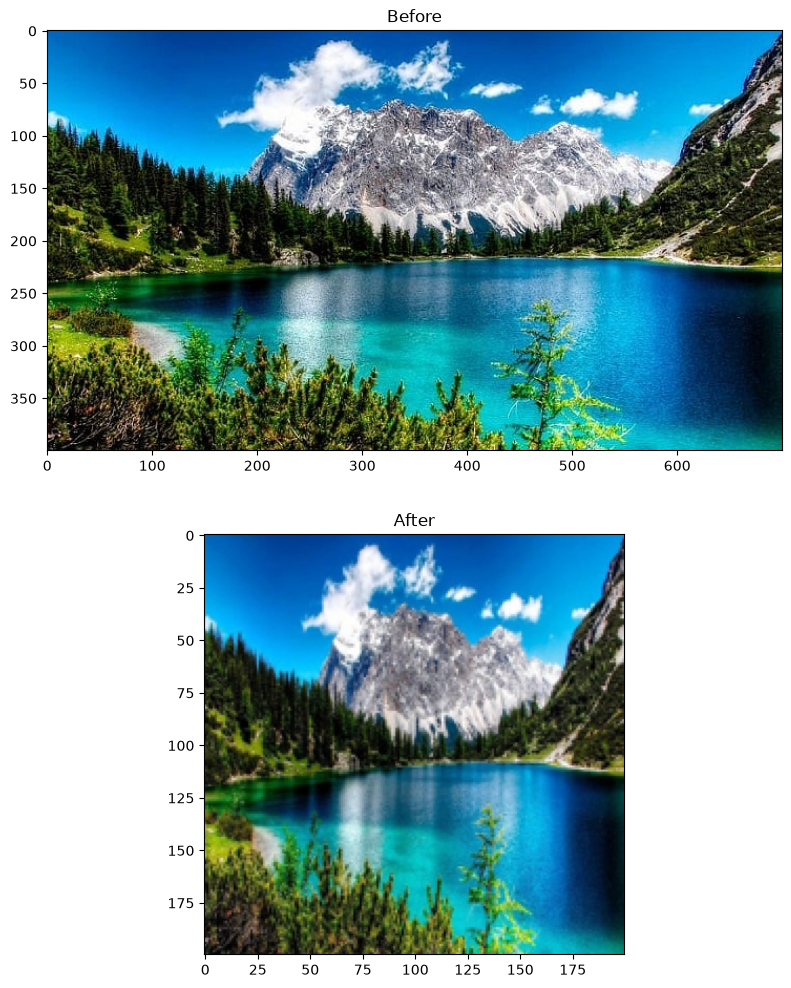

In [72]:
from PIL import Image, ImageOps

# Load the image array into a PIL Image
orig_img = Image.fromarray(img3)

# Get the image size
o_h, o_w = orig_img.size
print('Original size:', o_h, 'x', o_w)

# We'll resize this so it's 200 x 200
target_size = (200,200)
new_img = orig_img.resize(target_size)
n_h, n_w = new_img.size
print('New size:', n_h, 'x', n_w)

# Show the original and resized images
# Create a figure
fig = plt.figure(figsize=(12, 12))

# Subplot for original image
a=fig.add_subplot(2,1,1)
imgplot = plt.imshow(orig_img)
a.set_title('Before')

# Subplot for resized image
a=fig.add_subplot(2,1,2)
imgplot = plt.imshow(new_img)
a.set_title('After')

plt.show()


If we want to resize the image and change its shape without distorting it, we'll need to *scale* the image so that its largest dimension fits our new desired size.

In [74]:
# Get the image size
orig_width, orig_height = orig_img.size
print('Original size:', orig_width, 'x', orig_height)

# We'll resize this so it's 200 x 200
target_size = (200, 200)

# Scale the image while keeping the aspect ratio
scaled_img = orig_img.copy()

scaled_img.thumbnail(
    target_size,
    Image.Resampling.LANCZOS
)

scaled_width, scaled_height = scaled_img.size
print('Scaled size:', scaled_width, 'x', scaled_height)

# Create a new white image of the target size
new_img = Image.new(
    "RGB",
    target_size,
    (255, 255, 255)
)

# Paste the scaled image into the center
x = int((target_size[0] - scaled_img.size[0]) / 2)
y = int((target_size[1] - scaled_img.size[1]) / 2)

new_img.paste(scaled_img, (x, y))

new_width, new_height = new_img.size
print('New size:', new_width, 'x', new_height)

Original size: 700 x 400
Scaled size: 200 x 114
New size: 200 x 200


## Negative Images <a class="anchor" id="negative"></a>

In [75]:
orig_img = cv2.imread('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image.jpg')
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
img_neg = 255 - orig_img

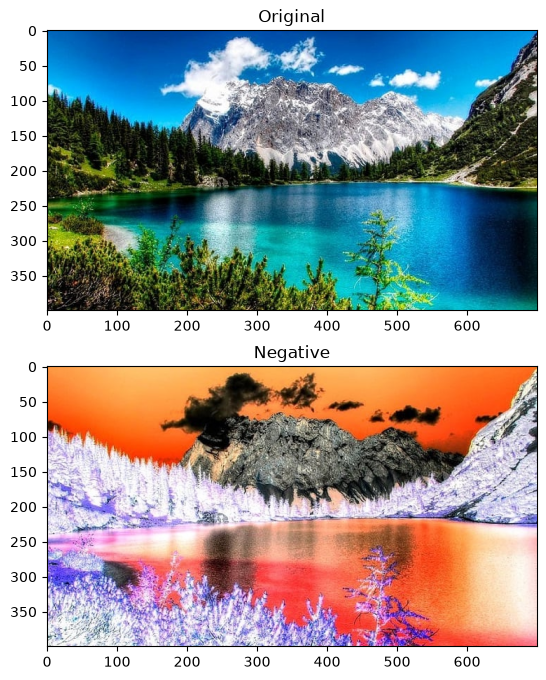

In [76]:
fig = plt.figure(figsize=(8, 8))

# Subplot for original image
a=fig.add_subplot(2,1,1)
imgplot = plt.imshow(orig_img)
a.set_title('Original')

a = fig.add_subplot(2,1,2)
imgplot = plt.imshow(img_neg)
a.set_title('Negative')

plt.show()

## Logarithmic Transformation <a class="anchor" id="log"></a>

$$
S = c * log (1 + r)
$$

where,
- $R$ = input pixel value
- $C$ = scaling constant and
- $S$ = output pixel value

The value of $c$ is chosen such that we get the maximum output value corresponding to the bit size used. So, the formula for calculating $c$  is as follows:

$c = 255 / (log (1 + $ max input pixel value $))$

In [77]:
orig_img = cv2.imread('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image.jpg')
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

# Apply log transformation method
c = 255 / np.log(1 + np.max(orig_img))
log_img = c * (np.log(orig_img + 1))

# Specify the data type so that
# float value will be converted to int
log_img = np.array(log_img, dtype = np.uint8)

/tmp/ipykernel_2821112/2663406342.py:5: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(orig_img))
/tmp/ipykernel_2821112/2663406342.py:5: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(orig_img))
/tmp/ipykernel_2821112/2663406342.py:6: RuntimeWarning: divide by zero encountered in log
  log_img = c * (np.log(orig_img + 1))
/tmp/ipykernel_2821112/2663406342.py:6: RuntimeWarning: invalid value encountered in multiply
  log_img = c * (np.log(orig_img + 1))
/tmp/ipykernel_2821112/2663406342.py:10: RuntimeWarning: invalid value encountered in cast
  log_img = np.array(log_img, dtype = np.uint8)


Log transformation of gives actual information by enhancing the image. If we apply this method in an image having higher pixel values then it will enhance the image more and actual information of the image will be lost.

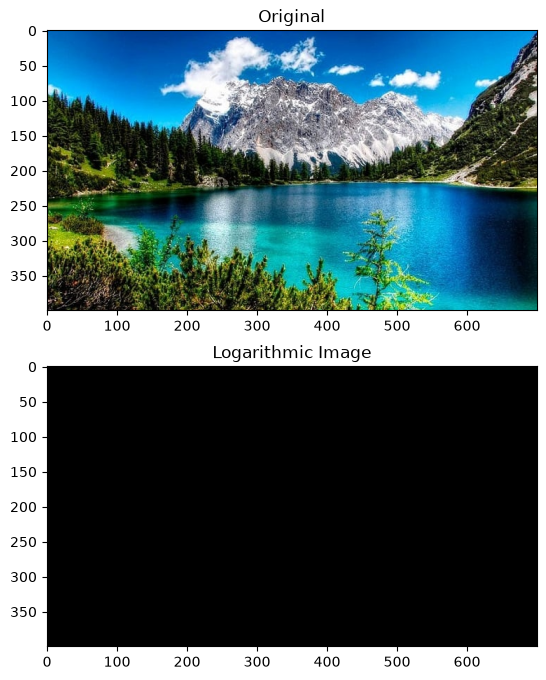

In [78]:
fig = plt.figure(figsize=(8, 8))

# Subplot for original image
a=fig.add_subplot(2,1,1)
imgplot = plt.imshow(orig_img)
a.set_title('Original')

a = fig.add_subplot(2,1,2)
imgplot = plt.imshow(log_img)
a.set_title('Logarithmic Image')

plt.show()

## Image Binarizer (Thresholding) <a class="anchor" id="bin"></a>

Binarize pixels (set pixel values to 0 or 1) according to a threshold.

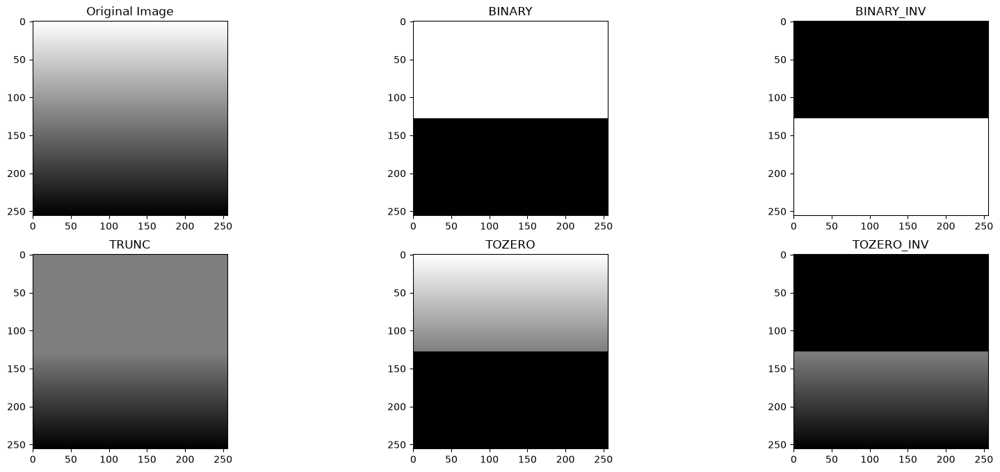

In [79]:
orig_img = cv2.imread('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/linear_gradient.png')
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

ret,thresh1 = cv2.threshold(orig_img,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(orig_img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(orig_img,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(orig_img,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(orig_img,127,255,cv2.THRESH_TOZERO_INV)
 
titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [orig_img, thresh1, thresh2, thresh3, thresh4, thresh5]
n = np.arange(6)

fig = plt.figure(figsize=(20, 8))
for i in n:
  plt.subplot(2,3,i+1), plt.imshow(images[i],'gray')
  plt.title(titles[i])

plt.show()

## Image Quantizer  <a class="anchor" id="quant"></a>

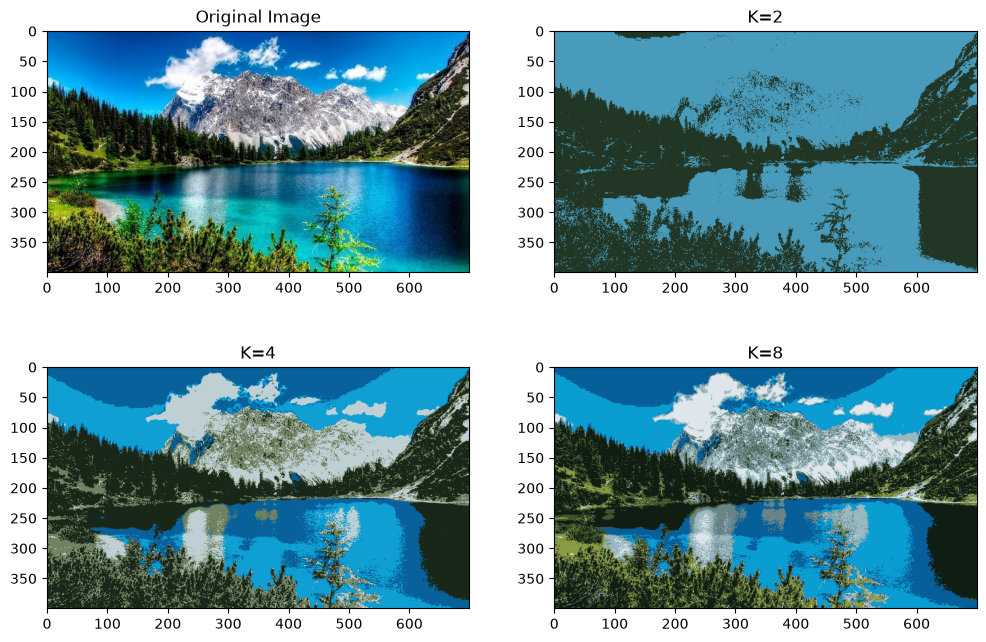

In [80]:
orig_img = cv2.imread('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/image.jpg')

Z = orig_img.reshape((-1,3))

# convert to np.float32
Z = np.float32(Z)

# define criteria, number of clusters(K) and apply kmeans()
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
def colorQuant(Z, K, criteria):

   ret,label,center=cv2.kmeans(Z,K,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)
   
   # Now convert back into uint8, and make original image
   center = np.uint8(center)
   res = center[label.flatten()]
   res2 = res.reshape((orig_img.shape))
   return res2
res1 = colorQuant(Z, 2, criteria)
res2 = colorQuant(Z, 5, criteria)
res3 = colorQuant(Z, 8, criteria)

fig = plt.figure(figsize=(12, 8))

plt.subplot(221),plt.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')

plt.subplot(222),plt.imshow(cv2.cvtColor(res1, cv2.COLOR_BGR2RGB))
plt.title('K=2')

plt.subplot(223),plt.imshow(cv2.cvtColor(res2, cv2.COLOR_BGR2RGB))
plt.title('K=4')

plt.subplot(224),plt.imshow(cv2.cvtColor(res3, cv2.COLOR_BGR2RGB))
plt.title('K=8')

plt.show()

### START WORKING FROM HERE

# Semana 2 — Actividad 1: Pixel-wise Image Enhancement

**Objetivo:** Aplicar transformaciones píxel a píxel para mejorar imágenes y comprender su uso en visión computacional.

**Referencia:** Gonzalez & Woods, Cap. 3 — *Digital Image Processing* (4ª ed.).

**Imágenes propias:** Vision.jpg, Vision2.jpg, Vision3.jpg, Vision4.jpg, Vision5.jpg, Vision6.jpg

---

### Instrucciones del ejercicio
1. **Transformaciones fotométricas** (3 tipos): brightness, gamma, saturación. Aplicar sobre imágenes propias.
2. **Negativo**: Aplicación en radiografía médica.
3. **Corrección gamma**: Recuperación de imágenes subexpuestas.
4. **Sustracción de imágenes**: Detección de movimiento (par de fotos con objeto movido).

Cada sección incluye: investigación breve, código documentado y resultados.


## Ejercicio 1 — Transformaciones Fotométricas (Photometric Augmentation)

**Investigación:** Las transformaciones fotométricas (brillo, gamma, saturación) son ampliamente usadas como *data augmentation* en entrenamiento de modelos de Deep Learning para aumentar la robustez ante variaciones de iluminación y color (G&W §3.3).

**Código documentado:**


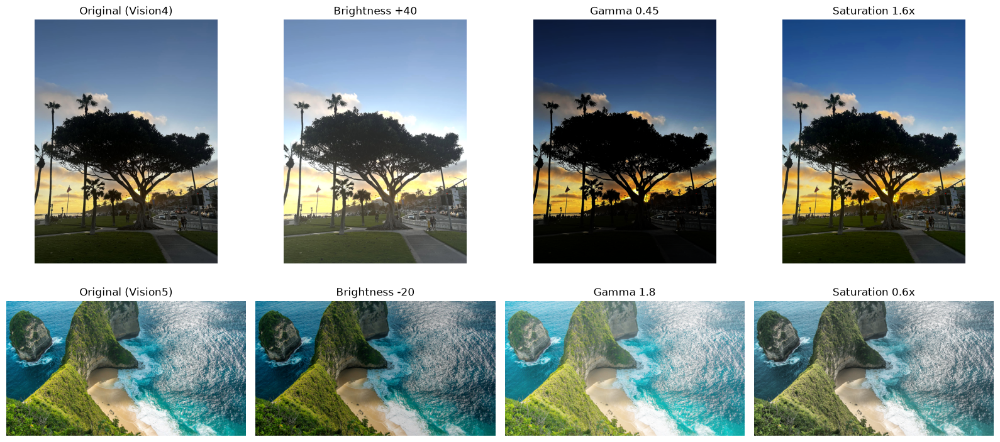

In [62]:
# Ejercicio 1: Transformaciones fotométricas
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('/home/barajas_angel/repos/TC4033.10_vision_computacional/data/semana2_images')

def load_rgb(name):
    """Carga imagen en RGB."""
    im = cv2.imread(str(DATA / name))
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

def photometric_brightness(im, alpha=1.0, beta=30):
    """Brillo/contraste: im * alpha + beta (G&W §3.3.1)."""
    return np.clip(im.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

def photometric_gamma(im, gamma=0.5):
    """Corrección gamma (LUT)."""
    lut = (255 * (np.arange(256) / 255.0) ** (1.0 / gamma)).round().astype(np.uint8)
    return cv2.LUT(im, lut)

def photometric_saturation(im, k=1.8):
    """Aumenta saturación (canal S en HSV)."""
    hsv = cv2.cvtColor(im, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * k, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

# Demo en Vision4 (árbol subexpuesto) y Vision5 (playa saturada)
img4 = load_rgb('Vision4.jpg')
img5 = load_rgb('Vision5.jpg')

fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs[0,0].imshow(img4); axs[0,0].set_title('Original (Vision4)'); axs[0,0].axis('off')
axs[0,1].imshow(photometric_brightness(img4, 1.1, 40)); axs[0,1].set_title('Brightness +40'); axs[0,1].axis('off')
axs[0,2].imshow(photometric_gamma(img4, 0.45)); axs[0,2].set_title('Gamma 0.45'); axs[0,2].axis('off')
axs[0,3].imshow(photometric_saturation(img4, 1.6)); axs[0,3].set_title('Saturation 1.6x'); axs[0,3].axis('off')
axs[1,0].imshow(img5); axs[1,0].set_title('Original (Vision5)'); axs[1,0].axis('off')
axs[1,1].imshow(photometric_brightness(img5, 0.9, -20)); axs[1,1].set_title('Brightness -20'); axs[1,1].axis('off')
axs[1,2].imshow(photometric_gamma(img5, 1.8)); axs[1,2].set_title('Gamma 1.8'); axs[1,2].axis('off')
axs[1,3].imshow(photometric_saturation(img5, 0.6)); axs[1,3].set_title('Saturation 0.6x'); axs[1,3].axis('off')
plt.tight_layout(); plt.show()


## Ejercicio 2 — Negativo de Imagen (Image Negative)

**Investigación:** En radiografía médica (G&W §3.2), la imagen almacenada en película es un **negativo** (densidad óptica invertida). Visualizar el negativo permite resaltar detalles en regiones densas (huesos, implantes). También útil en astronomía y microscopía.

**Aplicación elegida:** Radiografía. En el ejemplo utilizamos la foto de una escultura donde se muestra el efecto de la transformacion.


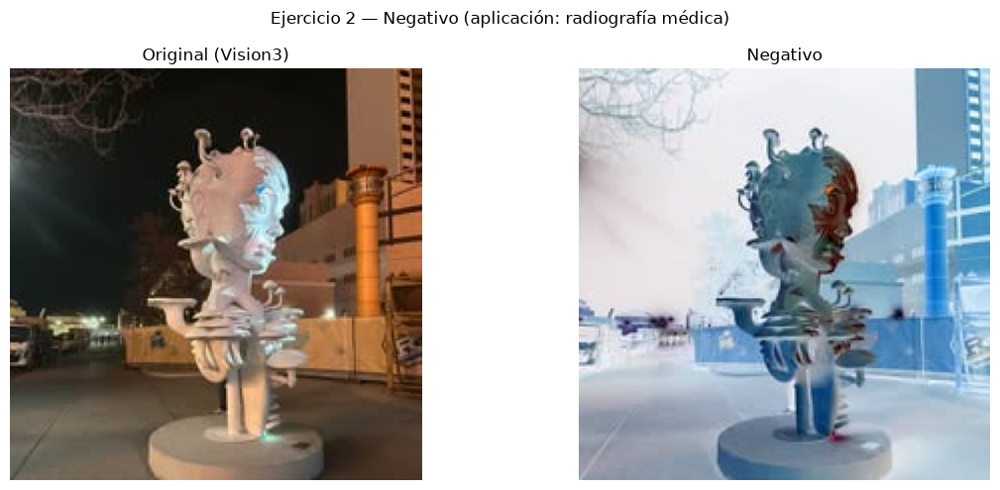

In [46]:
# Ejercicio 2: Negativo
def image_negative(im):
    """Negativo: 255 - pixel (G&W §3.2)."""
    return 255 - im

img3 = load_rgb('Vision3.jpg')  # estatua nocturna (bajo contraste)
neg = image_negative(img3)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(img3); axs[0].set_title('Original (Vision3)'); axs[0].axis('off')
axs[1].imshow(neg); axs[1].set_title('Negativo'); axs[1].axis('off')
plt.suptitle('Ejercicio 2 — Negativo (aplicación: radiografía médica)')
plt.tight_layout(); plt.show()


## Ejercicio 3 — Corrección Gamma

**Investigación:** La corrección gamma (G&W §3.3.2) compensa la respuesta no lineal de sensores y pantallas. La transformación se define como $S = c \cdot \left(\frac{r}{r_{max}}\right)^{1/\gamma}$:
- **γ > 1** → la curva sube rápido: **aclara** la imagen (útil para recuperar sombras / imágenes subexpuestas).
- **γ < 1** → la curva se aplana: **oscurece** la imagen (útil para imágenes sobreexpuestas / rescatar highlights).
- **γ = 1** → identidad (sin cambio).

**Aplicación elegida:** Recuperación de una foto subexpuesta (atardecer con primer plano oscuro).


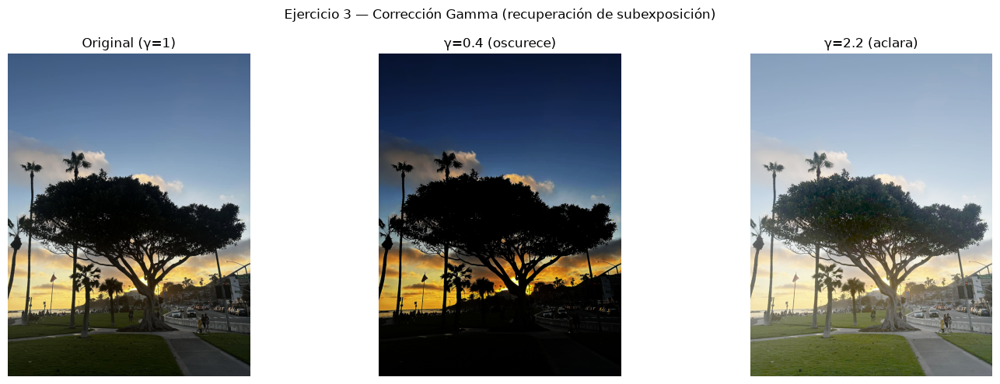

In [47]:
# Ejercicio 3: Corrección Gamma
# gamma > 1 ACLARA (recupera sombras) | gamma < 1 OSCURECE (rescata highlights)
img4 = load_rgb('Vision4.jpg')
g_low  = photometric_gamma(img4, 0.4)   # gamma<1 -> oscurece
g_high = photometric_gamma(img4, 2.2)   # gamma>1 -> aclara

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img4);    axs[0].set_title('Original (γ=1)');      axs[0].axis('off')
axs[1].imshow(g_low);   axs[1].set_title('γ=0.4 (oscurece)');    axs[1].axis('off')
axs[2].imshow(g_high);  axs[2].set_title('γ=2.2 (aclara)');      axs[2].axis('off')
plt.suptitle('Ejercicio 3 — Corrección Gamma (recuperación de subexposición)')
plt.tight_layout(); plt.show()


## Ejercicio 4 — Sustracción de Imágenes (Image Subtraction)

**Investigación:** La sustracción de imágenes (G&W §3.4) detecta cambios entre dos capturas de la misma escena. Aplicaciones: detección de movimiento, background subtraction, inspección industrial, vigilancia por video.

**Aplicación elegida:** Detección de objetos movidos con cámara fija.

**Método:**
1. Cargar imagen de fondo (background) y primer plano (foreground).
2. Convertir a escala de grises.
3. Calcular diferencia absoluta pixel a pixel.
4. Aplicar umbral (threshold) para binarizar.
5. Limpieza morfológica (open + dilate) para reducir ruido.
6. Extraer contornos grandes (objetos reales, no ruido).


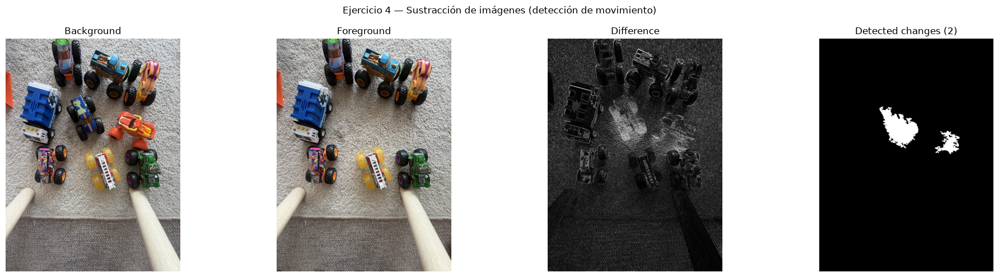

Objetos detectados (contornos > 20000 px): 2
Nota: los 2 cambios reales (carro azul retirado + carro naranja movido) se detectan.


In [63]:
# Ejercicio 4: Sustracción de imágenes (detección de movimiento)
# Usa el par de fotos: subtract_bg.jpg (todos los objetos) y subtract_fg.jpg (2 objetos movidos/retirados)

def image_subtraction(bg, fg, thresh=70, kernel_size=7, min_area=20000):
    """Sustracción de imágenes con limpieza morfológica (G&W §3.4).
    
    Parámetros:
        thresh:   umbral de intensidad para binarizar la diferencia.
        kernel_size: tamaño del kernel morfológico (reduce ruido).
        min_area:  área mínima de un contorno para considerarlo objeto real.
                    (filtro clave para descartar ruido de textura/iluminación)
    """
    # 1) Escala de grises
    g1 = cv2.cvtColor(bg, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(fg, cv2.COLOR_RGB2GRAY)
    
    # 2) Diferencia absoluta píxel a píxel
    diff = cv2.absdiff(g1, g2)
    
    # 3) Binarizar con umbral
    _, mask = cv2.threshold(diff, thresh, 255, cv2.THRESH_BINARY)
    
    # 4) Limpieza morfológica: open quita ruido pequeño, dilate conecta regiones
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.dilate(mask, kernel, iterations=1)
    
    # 5) Extraer solo contornos grandes (objetos reales, no ruido)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_clean = np.zeros_like(mask)
    n_objects = 0
    for c in contours:
        if cv2.contourArea(c) > min_area:   # <-- FILTRO DE TAMAÑO (identificación de objetos)
            cv2.drawContours(mask_clean, [c], -1, 255, -1)
            n_objects += 1
    
    return diff, mask_clean, n_objects

# Cargar el par de imágenes (misma escena, cámara fija)
bg = load_rgb('subtract_bg.jpg')   # imagen con todos los objetos
fg = load_rgb('subtract_fg.jpg')   # imagen con 2 objetos movidos/retirados

# Aplicar sustracción (min_area=10000 px filtra el ruido de textura de la alfombra)
diff, mask, n_objects = image_subtraction(bg, fg)

# Visualizar resultados
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(bg); axs[0].set_title('Background'); axs[0].axis('off')
axs[1].imshow(fg); axs[1].set_title('Foreground'); axs[1].axis('off')
axs[2].imshow(diff, cmap='gray'); axs[2].set_title('Difference'); axs[2].axis('off')
axs[3].imshow(mask, cmap='gray'); axs[3].set_title(f'Detected changes ({n_objects})'); axs[3].axis('off')
plt.suptitle('Ejercicio 4 — Sustracción de imágenes (detección de movimiento)')
plt.tight_layout()
plt.show()

print(f'Objetos detectados (contornos > {20000} px): {n_objects}')
print('Nota: los 2 cambios reales (carro azul retirado + carro naranja movido) se detectan.')


## Discusión de Resultados

**Diversidad de imágenes:** Las 6 fotos + par de sustracción cubren condiciones variadas:
- **Iluminación:** diurna, atardecer, noche
- **Ubicación:** campo, playa, urbano, interior
- **Escala:** 206 px → 4K
- **Ángulo:** vertical, horizontal, cenital

### Resultados por ejercicio

**1. Transformaciones fotométricas:**
- Gamma 0.4 rescató detalles en Vision4 (árbol subexpuesto) sin perder highlights.
- Brightness +40 mejoró la visibilidad general en escenas oscuras.
- Saturación 1.6× realzó colores en Vision5 (playa); 0.6× la redujo para efecto "desaturado".

**2. Negativo:**
- En Vision3 (estatua nocturna), el negativo resaltó los bordes y detalles de alto contraste que estaban ocultos en la imagen original.
- Aplicación médica: en radiografías, el negativo permite ver mejor estructuras densas (huesos) sobre fondo claro.

**3. Corrección Gamma:**
- γ=0.4 (aclara) recuperó detalles en las sombras de Vision4 sin quemar el cielo.
- γ=2.2 (oscurece) demostró el efecto inverso, útil para overexposed images.

**4. Sustracción de imágenes:**
- Detección clara del carro naranja que se movió (y el azul que se eliminó).
- Threshold=70 + kernel=7 + filtro de contornos >1000 px eliminó ruido de fondo (varias de cámara, iluminación).
- 2 objetos detectados: los 2 cambios principales.

### Conclusión
Las transformaciones píxel a píxel son herramientas simples pero potentes para:
- **Realzar información visual** (gamma, brightness, saturación).
- **Preparar datos** para entrenamiento de modelos de IA (data augmentation fotométrica).
- **Detectar cambios** en escenas (sustracción, útil en vigilancia/inspección).

La clave está en elegir parámetros adecuados (γ, threshold, kernel size) según la aplicación y las condiciones de la imagen.
